In [1]:
import os
os.chdir('/workspace/5f29edb4-3009-4bd2-9f9f-6b4d15536790')
print(os.listdir('.'))


['.kernel_llm_logs_1.txt', 'weil_quadratic_form.py', '_zeros.py', 'memory', '.prompts', '-v8-validated-data.md', '.config']


In [2]:
import subprocess
print(subprocess.check_output(['wc', '-l', 'weil_quadratic_form.py', '_zeros.py']).decode())


 164 weil_quadratic_form.py
 283 _zeros.py
 447 total



In [3]:
import sys, os
sys.path.insert(0, '/workspace/5f29edb4-3009-4bd2-9f9f-6b4d15536790')
from _zeros import zeta_zeros
import time

# Pre-generate 5000 zeros (will cache)
t0 = time.time()
zz_all = zeta_zeros(5000, dps=30)
print(f"got {len(zz_all)} zeros in {time.time()-t0:.1f}s")
print("first 3:", [float(z) for z in zz_all[:3]])
print("last 3:", [float(z) for z in zz_all[-3:]])


TimeoutError: Code execution timed out after 900.0 seconds

In [4]:
# check cache status
import os
cache_dir = '/workspace/5f29edb4-3009-4bd2-9f9f-6b4d15536790/cache'
if os.path.exists(cache_dir):
 print(os.listdir(cache_dir))
else:
 print("no cache yet")


[]


In [5]:
# mpmath zetazero is too slow at 5000 zeros. Use cached Odlyzko tables instead, or use lower dps.
# Actually for our analysis we only need γ values to maybe 6-8 decimal places.
# Let me try lower dps and parallel batches. Or just use the LMFDB known list.
# 
# Best approach: use mpmath.zetazero with dps=15 (lower precision, faster).
import mpmath as mp
mp.mp.dps = 15
import time
t0 = time.time()
z1 = mp.zetazero(1).imag
print(f"zero 1: {z1} in {time.time()-t0:.3f}s")

t0 = time.time()
z100 = mp.zetazero(100).imag
print(f"zero 100: {z100} in {time.time()-t0:.3f}s")

t0 = time.time()
z1000 = mp.zetazero(1000).imag
print(f"zero 1000: {z1000} in {time.time()-t0:.3f}s")


zero 1: 14.1347251417347 in 0.014s
zero 100: 236.524229665816 in 0.126s


zero 1000: 1419.422480946 in 0.232s


In [6]:
# with dps=15 it's much faster. Let me estimate time for 5000.
import time, mpmath as mp
mp.mp.dps = 15
t0 = time.time()
z5000 = mp.zetazero(5000).imag
print(f"zero 5000: {z5000} in {time.time()-t0:.2f}s")


zero 5000: 5447.8619983013 in 0.45s


In [7]:
# OK so individually each zero is fast at dps=15. But 5000 zeros at avg ~0.3s = 25min.
# Use the LMFDB / Odlyzko table or compute in batches. Let's just compute serially with low dps.
# Time estimate: maybe 5-15 minutes. We'll generate up to 5000 once and cache.
import mpmath as mp
mp.mp.dps = 15
import time, pickle, os
cache_dir = '/workspace/5f29edb4-3009-4bd2-9f9f-6b4d15536790/cache'
os.makedirs(cache_dir, exist_ok=True)
cache_path = os.path.join(cache_dir, 'zeta_zeros_5000_dps15.pkl')

if os.path.exists(cache_path):
 with open(cache_path, 'rb') as f:
 zeros = pickle.load(f)
 print(f"loaded {len(zeros)} from cache")
else:
 zeros = []
 t0 = time.time()
 for n in range(1, 5001):
 zeros.append(float(mp.zetazero(n).imag))
 if n % 500 == 0:
 print(f" n={n}, t={time.time()-t0:.1f}s, last γ={zeros[-1]:.4f}")
 with open(cache_path, 'wb') as f:
 pickle.dump(zeros, f)
 print(f"done in {time.time()-t0:.1f}s")
print(f"first 3: {zeros[:3]}")
print(f"last 3: {zeros[-3:]}")


TimeoutError: Code execution timed out after 900.0 seconds

In [8]:
# Single-cell run timed out at 900s. Need to chunk this. Let me check what we have.
import os, pickle
cache_dir = '/workspace/5f29edb4-3009-4bd2-9f9f-6b4d15536790/cache'
print(os.listdir(cache_dir))


[]


In [9]:
# Let me try Odlyzko's table — there are publicly available files of pre-computed zeta zeros.
# LMFDB has them. Let's just fetch them.
import urllib.request
url = "https://www.lmfdb.org/zeros/zeta/?download=zeros&n=5000&t=10000&format=text"
# Actually, simpler: use Odlyzko's table directly
url2 = "https://www-users.cse.umn.edu/~odlyzko/zeta_tables/zeros1"
try:
 with urllib.request.urlopen(url2, timeout=60) as r:
 data = r.read().decode()
 print(data[:500])
 print('---')
 print(f"length: {len(data)}")
except Exception as e:
 print("fail:", e)


 14.134725142
 21.022039639
 25.010857580
 30.424876126
 32.935061588
 37.586178159
 40.918719012
 43.327073281
 48.005150881
 49.773832478
 52.970321478
 56.446247697
 59.347044003
 60.831778525
 65.112544048
 67.079810529
 69.546401711
 72.067157674
 75.704690699
 77.144840069
 79.337375020
 82.910380854
 84.735492981
 87.425274613
 88.809111208
 92.491899271
 94.651344041
 95.870634
---
length: 1800000


In [10]:
# Excellent! Parse Odlyzko's table
lines = data.strip().split('\n')
zeros_odl = [float(line.strip()) for line in lines if line.strip()]
print(f"got {len(zeros_odl)} zeros from Odlyzko")
print(f"first 3: {zeros_odl[:3]}")
print(f"zeros 4999, 5000: {zeros_odl[4998:5001]}")
print(f"last 3: {zeros_odl[-3:]}")


got 100000 zeros from Odlyzko
first 3: [14.134725142, 21.022039639, 25.01085758]
zeros 4999, 5000: [5446.765247873, 5447.861998301, 5448.908413286]
last 3: [74919.075161121, 74920.259793259, 74920.827498994]


In [11]:
# Save zeros to a cache file matching the _zeros module conventions
import pickle, os
cache_dir = '/workspace/5f29edb4-3009-4bd2-9f9f-6b4d15536790/cache'
import mpmath as mp
mp.mp.dps = 15

zeros_mpf = [mp.mpf(z) for z in zeros_odl[:5000]]
# Save in format the module would have written it
with open(os.path.join(cache_dir, 'zeta_zeros_N5000_dps15.pkl'), 'wb') as f:
 pickle.dump(zeros_mpf, f)
# Also save a plain float version for fast use
with open(os.path.join(cache_dir, 'zeta_zeros_5000_float.pkl'), 'wb') as f:
 pickle.dump(zeros_odl[:5000], f)
print("cached")
print(os.listdir(cache_dir))


cached
['zeta_zeros_5000_float.pkl', 'zeta_zeros_N5000_dps15.pkl']


In [12]:
# Now plan: Q(T0, sigma, J, X, H) — compute λ_min for grid of (X, H) at two parameter points
# X: {1e4, 1e5, 5e5, 1e6}, H: {1000, 2500, 5000}
# Points: (T0,σ,J) = (46.13, 1, 10) and (85.7, 2, 10)
# 
# Test the engine quickly first.
import importlib, weil_quadratic_form as wqf
importlib.reload(wqf)
import numpy as np
zeros = np.array(zeros_odl[:1000], dtype=np.float64)

t0_test = 46.13
import time
t_start = time.time()
Q, comps = wqf.compute_Q(zeros, T0=t0_test, sigma=1.0, J=10, primes_cutoff=10_000)
elapsed = time.time() - t_start
print(f"compute_Q in {elapsed:.2f}s")
lam = np.linalg.eigvalsh(Q)
print(f"λ_min = {lam[0]:.6e}")
print(f"λ_max = {lam[-1]:.6e}")
print(f"all eigvals: {lam}")


compute_Q in 0.17s
λ_min = -2.559639e-02
λ_max = 4.559684e-02
all eigvals: [-2.55963893e-02 -8.59402490e-04 -2.21783877e-06 -3.74744096e-08
 1.56495125e-11 1.06396526e-10 6.05487434e-09 8.35821780e-06
 3.28810574e-04 4.55968374e-02]


In [13]:
# Engine works. Time scales with primes_cutoff. Let me time X=1e6:
import time
t_start = time.time()
Q, comps = wqf.compute_Q(zeros, T0=46.13, sigma=1.0, J=10, primes_cutoff=1_000_000)
elapsed = time.time() - t_start
print(f"X=1e6: compute_Q in {elapsed:.2f}s")
lam = np.linalg.eigvalsh(Q)
print(f"λ_min = {lam[0]:.6e}")


X=1e6: compute_Q in 6.79s
λ_min = -5.795572e-09


In [14]:
# Great. λ_min becomes ~ 1e-9 at X=1e6, vs ~ -1e-2 at X=1e4 for H=1000.
# 
# Key insight: M_primes depends only on (T0, sigma, J, X) — not on H (zeros).
# M_zeros depends only on H (and T0, sigma, J).
# So we can compute M_primes once per (X) for each parameter point, and M_zeros once per (H).
# Then combine.
# 
# Let me build this efficiently.

import importlib, weil_quadratic_form as wqf
importlib.reload(wqf)
import numpy as np

# Pre-compute components separately
def compute_M_primes(T0, sigma, J, X, n_nodes_quad=200):
 from sympy import primerange
 primes_list = list(primerange(2, X + 1))
 u_vals, weights = [], []
 for p in primes_list:
 k = 1
 pk = p
 while pk <= X:
 u_vals.append(k * np.log(p))
 weights.append(np.log(p) / np.sqrt(pk))
 k += 1
 pk *= p
 u_vals = np.array(u_vals)
 weights = np.array(weights)
 M_primes = np.zeros((J, J))
 chunk = 2000
 for i in range(0, len(u_vals), chunk):
 u_chunk = u_vals[i:i+chunk]
 w_chunk = weights[i:i+chunk]
 g_chunk = wqf._g_at_u(u_chunk, sigma, T0, J, n_nodes_quad)
 M_primes += np.sum(w_chunk[:, None, None] * np.real(g_chunk), axis=0) / np.pi
 return M_primes

def compute_M_zeros(zeros_array, T0, sigma, J):
 g_all = np.concatenate([zeros_array, -zeros_array])
 phi = wqf._phi_at_points(g_all, sigma, T0, J)
 return phi.T @ phi

def compute_M_arch_polar(T0, sigma, J, n_nodes_quad=200):
 from scipy.special import digamma, gammaln
 from numpy.polynomial.hermite import hermgauss
 x, w = hermgauss(n_nodes_quad)
 H = np.zeros((J, n_nodes_quad))
 H[0] = 1.0
 if J > 1:
 H[1] = 2 * x
 for n in range(1, J - 1):
 H[n + 1] = 2 * x * H[n] - 2 * n * H[n - 1]
 norm = np.array([0.5 * (k * np.log(2) + gammaln(k + 1)) for k in range(J)])
 norm_ij = norm[:, None] + norm[None, :] + 0.5 * np.log(np.pi)
 exp_neg_norm = np.exp(-norm_ij)
 t_nodes = T0 + sigma * x
 psi_vals = np.real(digamma(0.25 + 0.5j * t_nodes))
 diag = w * psi_vals
 HP = H * diag[None, :]
 M_arch = (HP @ H.T) * exp_neg_norm / (2 * np.pi)
 M_polar = -(np.log(np.pi) / (2 * np.pi)) * np.eye(J)
 return M_arch, M_polar

# Test
M_primes_X1e4 = compute_M_primes(46.13, 1.0, 10, 10000)
M_arch, M_polar = compute_M_arch_polar(46.13, 1.0, 10)
M_zeros_1000 = compute_M_zeros(np.array(zeros_odl[:1000]), 46.13, 1.0, 10)
M_arith = M_polar + M_arch - M_primes_X1e4
Q = M_zeros_1000 - M_arith
Q = 0.5 * (Q + Q.T)
lam = np.linalg.eigvalsh(Q)
print(f"split: λ_min = {lam[0]:.6e}")

# Compare with original
Q_orig, _ = wqf.compute_Q(np.array(zeros_odl[:1000]), 46.13, 1.0, 10, primes_cutoff=10000)
lam_orig = np.linalg.eigvalsh(Q_orig)
print(f"orig: λ_min = {lam_orig[0]:.6e}")


split: λ_min = -2.559639e-02
orig: λ_min = -2.559639e-02


In [15]:
# Perfect, matches. Now compute the full grid efficiently.
import time
zeros_arr = np.array(zeros_odl[:5000], dtype=np.float64)

param_points = {
 'optimal': (46.13, 1.0, 10),
 'L_DH': (85.7, 2.0, 10),
}
X_grid = [10_000, 100_000, 500_000, 1_000_000]
H_grid = [1000, 2500, 5000]

results = {}

for name, (T0, sigma, J) in param_points.items():
 print(f"\n=== {name}: T0={T0}, σ={sigma}, J={J} ===")
 M_arch, M_polar = compute_M_arch_polar(T0, sigma, J)
 # Pre-compute M_zeros for each H
 Mz = {H: compute_M_zeros(zeros_arr[:H], T0, sigma, J) for H in H_grid}
 # Pre-compute M_primes for each X
 Mp = {}
 for X in X_grid:
 t0 = time.time()
 Mp[X] = compute_M_primes(T0, sigma, J, X)
 print(f" M_primes X={X:>7}: {time.time()-t0:.2f}s")
 for X in X_grid:
 for H in H_grid:
 M_arith = M_polar + M_arch - Mp[X]
 Q = Mz[H] - M_arith
 Q = 0.5 * (Q + Q.T)
 lam = np.linalg.eigvalsh(Q)
 results[(name, X, H)] = {
 'lam_min': float(lam[0]),
 'lam_max': float(lam[-1]),
 'all_eigvals': lam.tolist(),
 }
 print(f" X={X:>7}, H={H:>4}: λ_min = {lam[0]:+.4e}, |λ_min| = {abs(lam[0]):.4e}")



=== optimal: T0=46.13, σ=1.0, J=10 ===
 M_primes X= 10000: 0.12s


 M_primes X= 100000: 0.82s


 M_primes X= 500000: 3.50s


 M_primes X=1000000: 6.89s
 X= 10000, H=1000: λ_min = -2.5596e-02, |λ_min| = 2.5596e-02
 X= 10000, H=2500: λ_min = -2.5596e-02, |λ_min| = 2.5596e-02
 X= 10000, H=5000: λ_min = -2.5596e-02, |λ_min| = 2.5596e-02
 X= 100000, H=1000: λ_min = -6.0984e-05, |λ_min| = 6.0984e-05
 X= 100000, H=2500: λ_min = -6.0984e-05, |λ_min| = 6.0984e-05
 X= 100000, H=5000: λ_min = -6.0984e-05, |λ_min| = 6.0984e-05
 X= 500000, H=1000: λ_min = -2.3631e-07, |λ_min| = 2.3631e-07
 X= 500000, H=2500: λ_min = -2.3631e-07, |λ_min| = 2.3631e-07
 X= 500000, H=5000: λ_min = -2.3631e-07, |λ_min| = 2.3631e-07
 X=1000000, H=1000: λ_min = -5.7956e-09, |λ_min| = 5.7956e-09
 X=1000000, H=2500: λ_min = -5.7956e-09, |λ_min| = 5.7956e-09
 X=1000000, H=5000: λ_min = -5.7956e-09, |λ_min| = 5.7956e-09

=== L_DH: T0=85.7, σ=2.0, J=10 ===
 M_primes X= 10000: 0.13s


 M_primes X= 100000: 0.85s


 M_primes X= 500000: 3.50s


 M_primes X=1000000: 6.73s
 X= 10000, H=1000: λ_min = -4.6196e-10, |λ_min| = 4.6196e-10
 X= 10000, H=2500: λ_min = -4.6196e-10, |λ_min| = 4.6196e-10
 X= 10000, H=5000: λ_min = -4.6196e-10, |λ_min| = 4.6196e-10
 X= 100000, H=1000: λ_min = -4.6196e-10, |λ_min| = 4.6196e-10
 X= 100000, H=2500: λ_min = -4.6196e-10, |λ_min| = 4.6196e-10
 X= 100000, H=5000: λ_min = -4.6196e-10, |λ_min| = 4.6196e-10
 X= 500000, H=1000: λ_min = -4.5927e-10, |λ_min| = 4.5927e-10
 X= 500000, H=2500: λ_min = -4.5927e-10, |λ_min| = 4.5927e-10
 X= 500000, H=5000: λ_min = -4.5927e-10, |λ_min| = 4.5927e-10
 X=1000000, H=1000: λ_min = -2.0627e-07, |λ_min| = 2.0627e-07
 X=1000000, H=2500: λ_min = -2.0627e-07, |λ_min| = 2.0627e-07
 X=1000000, H=5000: λ_min = -2.0627e-07, |λ_min| = 2.0627e-07


In [16]:
# Interesting observations:
# 1) For optimal point (T0=46.13, σ=1): λ_min decreases dramatically with X. 
# But it does NOT change with H — because the Hermite-Gauss basis at (T0=46.13,σ=1)
# is supported in [≈40, ≈52], i.e., within first ~50 zeros' window. H=1000 already
# covers γ up to ~1419, far beyond. So the zero-side sum is saturated for H ≥ 1000.
# 2) For L_DH point (T0=85.7, σ=2, J=10): the basis is wider; window roughly [85.7 - 10, 85.7 + 10] = [75,95]
# so first ~70 zeros suffice. Again saturated.
# 3) For L_DH point, λ_min stays at ~5e-10 for X up to 5e5, then increases at X=1e6.
# That's puzzling — likely numerical floor issues with quadrature accuracy at higher X.
# The n_nodes_quad=200 may be insufficient. Let me investigate this.

# Check: is the numerical quadrature accurate enough for X=1e6 at T0=85.7?
# The integrand g(u) for primes at u=ln(p) up to ln(1e6) ≈ 13.8.
# Phase oscillates as e^{-i*omega*x} with omega = sigma*u = 2 * 13.8 ≈ 27.6
# Plus phase e^{-i*u*T0} ~ e^{-i*13.8*85.7} = highly oscillatory.
# 200 Gauss-Hermite nodes may not capture this. Let me try n_nodes_quad=500 for the L_DH point.

def compute_M_primes_v2(T0, sigma, J, X, n_nodes_quad):
 return compute_M_primes(T0, sigma, J, X, n_nodes_quad=n_nodes_quad)

# Test with more quadrature nodes at L_DH point, X=1e6
for nnq in [200, 400, 800]:
 import time
 t0 = time.time()
 Mp = compute_M_primes_v2(85.7, 2.0, 10, 1_000_000, nnq)
 M_arch85, M_polar85 = compute_M_arch_polar(85.7, 2.0, 10, n_nodes_quad=nnq)
 Mz = compute_M_zeros(zeros_arr[:1000], 85.7, 2.0, 10)
 Q = Mz - (M_polar85 + M_arch85 - Mp)
 Q = 0.5*(Q + Q.T)
 lam = np.linalg.eigvalsh(Q)
 print(f"nnq={nnq}: λ_min={lam[0]:+.4e}, time={time.time()-t0:.1f}s")


nnq=200: λ_min=-2.0627e-07, time=6.7s


/app/kernel_env/lib/python3.13/site-packages/numpy/polynomial/hermite.py:1648: RuntimeWarning: divide by zero encountered in divide
 w = 1 / (fm * fm)
/app/kernel_env/lib/python3.13/site-packages/numpy/polynomial/hermite.py:1648: RuntimeWarning: overflow encountered in divide
 w = 1 / (fm * fm)
/app/kernel_env/lib/python3.13/site-packages/numpy/polynomial/hermite.py:1651: RuntimeWarning: overflow encountered in add
 w = (w + w[::-1]) / 2
/app/kernel_env/lib/python3.13/site-packages/numpy/polynomial/hermite.py:1655: RuntimeWarning: invalid value encountered in multiply
 w *= np.sqrt(np.pi) / w.sum()


LinAlgError: Eigenvalues did not converge

In [17]:
# Gauss-Hermite breaks for nnq>~200 because of overflow in weights computation. 
# Use scipy's roots_hermite which is more stable.
from scipy.special import roots_hermite
from scipy.special import digamma, gammaln

def _g_at_u_v2(u_array, sigma, T0, J, n_nodes=200):
 u_array = np.asarray(u_array, dtype=np.float64)
 x, w = roots_hermite(n_nodes)
 H = np.zeros((J, n_nodes))
 H[0] = 1.0
 if J > 1:
 H[1] = 2 * x
 for n in range(1, J - 1):
 H[n + 1] = 2 * x * H[n] - 2 * n * H[n - 1]
 norm = np.array([0.5 * (k * np.log(2) + gammaln(k + 1)) for k in range(J)])
 norm_ij = norm[:, None] + norm[None, :] + 0.5 * np.log(np.pi)
 exp_neg_norm = np.exp(-norm_ij)
 omega = sigma * u_array
 phase = np.exp(-1j * omega[:, None] * x[None, :])
 G_un = np.einsum("ik,mk,jk->mij", H, w * phase, H)
 G = G_un * exp_neg_norm
 phase_T0 = np.exp(-1j * u_array * T0)
 return G * phase_T0[:, None, None]

def compute_M_primes_v3(T0, sigma, J, X, n_nodes_quad=200):
 from sympy import primerange
 primes_list = list(primerange(2, X + 1))
 u_vals, weights = [], []
 for p in primes_list:
 k = 1
 pk = p
 while pk <= X:
 u_vals.append(k * np.log(p))
 weights.append(np.log(p) / np.sqrt(pk))
 k += 1
 pk *= p
 u_vals = np.array(u_vals)
 weights = np.array(weights)
 M_primes = np.zeros((J, J))
 chunk = 2000
 for i in range(0, len(u_vals), chunk):
 u_chunk = u_vals[i:i+chunk]
 w_chunk = weights[i:i+chunk]
 g_chunk = _g_at_u_v2(u_chunk, sigma, T0, J, n_nodes_quad)
 M_primes += np.sum(w_chunk[:, None, None] * np.real(g_chunk), axis=0) / np.pi
 return M_primes

def compute_M_arch_polar_v2(T0, sigma, J, n_nodes_quad=200):
 x, w = roots_hermite(n_nodes_quad)
 H = np.zeros((J, n_nodes_quad))
 H[0] = 1.0
 if J > 1:
 H[1] = 2 * x
 for n in range(1, J - 1):
 H[n + 1] = 2 * x * H[n] - 2 * n * H[n - 1]
 norm = np.array([0.5 * (k * np.log(2) + gammaln(k + 1)) for k in range(J)])
 norm_ij = norm[:, None] + norm[None, :] + 0.5 * np.log(np.pi)
 exp_neg_norm = np.exp(-norm_ij)
 t_nodes = T0 + sigma * x
 psi_vals = np.real(digamma(0.25 + 0.5j * t_nodes))
 diag = w * psi_vals
 HP = H * diag[None, :]
 M_arch = (HP @ H.T) * exp_neg_norm / (2 * np.pi)
 M_polar = -(np.log(np.pi) / (2 * np.pi)) * np.eye(J)
 return M_arch, M_polar

# Test
import time
for nnq in [200, 400, 600, 800, 1000]:
 t0 = time.time()
 Mp = compute_M_primes_v3(85.7, 2.0, 10, 1_000_000, nnq)
 M_arch85, M_polar85 = compute_M_arch_polar_v2(85.7, 2.0, 10, n_nodes_quad=nnq)
 Mz = compute_M_zeros(zeros_arr[:1000], 85.7, 2.0, 10)
 Q = Mz - (M_polar85 + M_arch85 - Mp)
 Q = 0.5*(Q + Q.T)
 lam = np.linalg.eigvalsh(Q)
 print(f"nnq={nnq}: λ_min={lam[0]:+.4e}, |λ_min|={abs(lam[0]):.4e}, time={time.time()-t0:.1f}s")


nnq=200: λ_min=-2.0627e-07, |λ_min|=2.0627e-07, time=4.5s


nnq=400: λ_min=-4.6197e-10, |λ_min|=4.6197e-10, time=8.4s


nnq=600: λ_min=-4.6197e-10, |λ_min|=4.6197e-10, time=12.0s


nnq=800: λ_min=-4.6188e-10, |λ_min|=4.6188e-10, time=15.6s


nnq=1000: λ_min=-4.6190e-10, |λ_min|=4.6190e-10, time=21.6s


In [18]:
# So for L_DH point, nnq=200 was insufficient at X=1e6. With nnq=400 it converges to ~4.62e-10.
# This is the actual noise floor and it doesn't decrease with X — because for σ=2, T0=85.7,
# the prime-side support is already saturated at quite small X. Interesting.
# Let me re-check optimal point too at nnq=400 to be safe.

for X in [10_000, 100_000, 500_000, 1_000_000]:
 Mp = compute_M_primes_v3(46.13, 1.0, 10, X, 400)
 M_arch, M_polar = compute_M_arch_polar_v2(46.13, 1.0, 10, n_nodes_quad=400)
 Mz = compute_M_zeros(zeros_arr[:1000], 46.13, 1.0, 10)
 Q = Mz - (M_polar + M_arch - Mp)
 Q = 0.5*(Q + Q.T)
 lam = np.linalg.eigvalsh(Q)
 print(f"optimal X={X:>7}: λ_min={lam[0]:+.4e}")


optimal X= 10000: λ_min=-2.5596e-02


optimal X= 100000: λ_min=-6.0984e-05


optimal X= 500000: λ_min=-2.3631e-07


optimal X=1000000: λ_min=-5.7955e-09


In [19]:
# For optimal point nnq=200 was already accurate. So nnq=400 is safe globally.
# Re-run the full grid with nnq=400 to be safe.

results = {}

for name, (T0, sigma, J) in param_points.items():
 print(f"\n=== {name}: T0={T0}, σ={sigma}, J={J} ===")
 M_arch, M_polar = compute_M_arch_polar_v2(T0, sigma, J, n_nodes_quad=400)
 Mz = {H: compute_M_zeros(zeros_arr[:H], T0, sigma, J) for H in H_grid}
 Mp = {}
 for X in X_grid:
 t0 = time.time()
 Mp[X] = compute_M_primes_v3(T0, sigma, J, X, n_nodes_quad=400)
 print(f" M_primes X={X:>7}: {time.time()-t0:.2f}s")
 for X in X_grid:
 for H in H_grid:
 Q = Mz[H] - (M_polar + M_arch - Mp[X])
 Q = 0.5*(Q + Q.T)
 lam = np.linalg.eigvalsh(Q)
 results[(name, X, H)] = {
 'lam_min': float(lam[0]),
 'lam_max': float(lam[-1]),
 'abs_lam_min': float(abs(lam[0])),
 'all_eigvals': lam.tolist(),
 }
 print(f"\n Grid {name}: |λ_min| table")
 print(f" {'X\\H':>10}" + ''.join(f"{H:>14}" for H in H_grid))
 for X in X_grid:
 row = f" {X:>10}"
 for H in H_grid:
 row += f" {abs(results[(name,X,H)]['lam_min']):.4e}"
 print(row)



=== optimal: T0=46.13, σ=1.0, J=10 ===
 M_primes X= 10000: 0.13s


 M_primes X= 100000: 0.99s


 M_primes X= 500000: 4.36s


 M_primes X=1000000: 8.21s

 Grid optimal: |λ_min| table
 X\H 1000 2500 5000
 10000 2.5596e-02 2.5596e-02 2.5596e-02
 100000 6.0984e-05 6.0984e-05 6.0984e-05
 500000 2.3631e-07 2.3631e-07 2.3631e-07
 1000000 5.7955e-09 5.7955e-09 5.7955e-09

=== L_DH: T0=85.7, σ=2.0, J=10 ===
 M_primes X= 10000: 0.13s


 M_primes X= 100000: 1.01s


 M_primes X= 500000: 4.27s


 M_primes X=1000000: 8.23s

 Grid L_DH: |λ_min| table
 X\H 1000 2500 5000
 10000 4.6197e-10 4.6197e-10 4.6197e-10
 100000 4.6197e-10 4.6197e-10 4.6197e-10
 500000 4.6192e-10 4.6192e-10 4.6192e-10
 1000000 4.6197e-10 4.6197e-10 4.6197e-10


In [20]:
# Now stable. Observations:
# - For (T0=46.13, σ=1): η decreases dramatically with X (10⁴ → 10⁶ gives 7 orders).
# - For (T0=85.7, σ=2): η is already saturated at X=10⁴, floor ~4.62e-10.
# - For both points, H has NO effect once H ≥ 1000 — the Hermite-Gauss basis is so localized 
# that all zeros relevant to the window are within ~few-σ of T0. 
# 
# To make H actually matter, we'd need to look at much smaller H (e.g. H=10, 50). 
# Let me probe finer H to show the H-dependence.

H_fine = [10, 25, 50, 100, 250, 500, 1000, 2500, 5000]
print("\n--- Finer H scan, X=1e6 ---")
for name, (T0, sigma, J) in param_points.items():
 print(f"\n{name}: T0={T0}, σ={sigma}, J={J}")
 M_arch, M_polar = compute_M_arch_polar_v2(T0, sigma, J, n_nodes_quad=400)
 Mp = compute_M_primes_v3(T0, sigma, J, 1_000_000, n_nodes_quad=400)
 for H in H_fine:
 Mz = compute_M_zeros(zeros_arr[:H], T0, sigma, J)
 Q = Mz - (M_polar + M_arch - Mp)
 Q = 0.5*(Q + Q.T)
 lam = np.linalg.eigvalsh(Q)
 # Find the relevant zero index
 rel = sum(1 for z in zeros_arr[:H] if abs(z - T0) < 4*sigma)
 print(f" H={H:>5}: |λ_min|={abs(lam[0]):.4e}, λ_min={lam[0]:+.4e}, zeros in window |γ-T0|<4σ: {rel}")



--- Finer H scan, X=1e6 ---

optimal: T0=46.13, σ=1.0, J=10


 H= 10: |λ_min|=7.7068e-09, λ_min=-7.7068e-09, zeros in window |γ-T0|<4σ: 3
 H= 25: |λ_min|=5.7955e-09, λ_min=-5.7955e-09, zeros in window |γ-T0|<4σ: 3
 H= 50: |λ_min|=5.7955e-09, λ_min=-5.7955e-09, zeros in window |γ-T0|<4σ: 3
 H= 100: |λ_min|=5.7955e-09, λ_min=-5.7955e-09, zeros in window |γ-T0|<4σ: 3
 H= 250: |λ_min|=5.7955e-09, λ_min=-5.7955e-09, zeros in window |γ-T0|<4σ: 3
 H= 500: |λ_min|=5.7955e-09, λ_min=-5.7955e-09, zeros in window |γ-T0|<4σ: 3
 H= 1000: |λ_min|=5.7955e-09, λ_min=-5.7955e-09, zeros in window |γ-T0|<4σ: 3
 H= 2500: |λ_min|=5.7955e-09, λ_min=-5.7955e-09, zeros in window |γ-T0|<4σ: 3
 H= 5000: |λ_min|=5.7955e-09, λ_min=-5.7955e-09, zeros in window |γ-T0|<4σ: 3

L_DH: T0=85.7, σ=2.0, J=10


 H= 10: |λ_min|=8.2802e-01, λ_min=-8.2802e-01, zeros in window |γ-T0|<4σ: 0
 H= 25: |λ_min|=5.2441e-01, λ_min=-5.2441e-01, zeros in window |γ-T0|<4σ: 5
 H= 50: |λ_min|=4.6197e-10, λ_min=-4.6197e-10, zeros in window |γ-T0|<4σ: 6
 H= 100: |λ_min|=4.6197e-10, λ_min=-4.6197e-10, zeros in window |γ-T0|<4σ: 6
 H= 250: |λ_min|=4.6197e-10, λ_min=-4.6197e-10, zeros in window |γ-T0|<4σ: 6
 H= 500: |λ_min|=4.6197e-10, λ_min=-4.6197e-10, zeros in window |γ-T0|<4σ: 6
 H= 1000: |λ_min|=4.6197e-10, λ_min=-4.6197e-10, zeros in window |γ-T0|<4σ: 6
 H= 2500: |λ_min|=4.6197e-10, λ_min=-4.6197e-10, zeros in window |γ-T0|<4σ: 6
 H= 5000: |λ_min|=4.6197e-10, λ_min=-4.6197e-10, zeros in window |γ-T0|<4σ: 6


In [21]:
# Confirmed: H plays the role of "saturating H" — once H is large enough to capture all zeros 
# in the Hermite-Gauss support, the floor saturates. This is the localization property of the detector.
# For both required H grid values {1000, 2500, 5000}, all are well above saturation.
# 
# Let me also do a finer X scan to capture the law cleanly.
X_fine = [1000, 3000, 10_000, 30_000, 100_000, 300_000, 1_000_000]

print("Fine X scan, H=2500")
fine_results = {}
for name, (T0, sigma, J) in param_points.items():
 print(f"\n{name}: T0={T0}, σ={sigma}")
 M_arch, M_polar = compute_M_arch_polar_v2(T0, sigma, J, n_nodes_quad=400)
 Mz = compute_M_zeros(zeros_arr[:2500], T0, sigma, J)
 for X in X_fine:
 Mp = compute_M_primes_v3(T0, sigma, J, X, n_nodes_quad=400)
 Q = Mz - (M_polar + M_arch - Mp)
 Q = 0.5*(Q + Q.T)
 lam = np.linalg.eigvalsh(Q)
 fine_results[(name, X)] = abs(float(lam[0]))
 print(f" X={X:>8}: |λ_min|={abs(lam[0]):.4e}")


Fine X scan, H=2500

optimal: T0=46.13, σ=1.0
 X= 1000: |λ_min|=1.5592e-01
 X= 3000: |λ_min|=7.0112e-02
 X= 10000: |λ_min|=2.5596e-02


 X= 30000: |λ_min|=1.1964e-03


 X= 100000: |λ_min|=6.0984e-05


 X= 300000: |λ_min|=5.3474e-07


 X= 1000000: |λ_min|=5.7955e-09

L_DH: T0=85.7, σ=2.0
 X= 1000: |λ_min|=4.9187e-10
 X= 3000: |λ_min|=4.6197e-10


 X= 10000: |λ_min|=4.6197e-10


 X= 30000: |λ_min|=4.6197e-10


 X= 100000: |λ_min|=4.6197e-10


 X= 300000: |λ_min|=4.6193e-10


 X= 1000000: |λ_min|=4.6197e-10


In [22]:
# Beautiful. For the optimal point, |λ_min| ~ exp(-c log X) — fit the power law / exponential decay.
import numpy as np
X_arr = np.array(X_fine, dtype=float)
y_opt = np.array([fine_results[('optimal', X)] for X in X_fine])
y_ldh = np.array([fine_results[('L_DH', X)] for X in X_fine])

# Fit log|λ| vs log X
logX = np.log10(X_arr)
log_y = np.log10(y_opt)
slope, intercept = np.polyfit(logX, log_y, 1)
print(f"optimal: log10|λ_min| ≈ {slope:.3f} * log10(X) + {intercept:.3f}")
print(f" i.e. |λ_min| ≈ {10**intercept:.3e} * X^{slope:.3f}")

# Try linear fit in log10|λ| vs sqrt(X)? Or vs X?
# Check: is decay closer to exp(-c sqrt(X)) or X^{-α}?
# Compute slope between consecutive points
print("\nlocal slopes d(log10|λ|)/d(log10 X):")
for i in range(len(X_fine)-1):
 s = (np.log10(y_opt[i+1])-np.log10(y_opt[i])) / (np.log10(X_arr[i+1])-np.log10(X_arr[i]))
 print(f" X={X_arr[i]:.0e} → {X_arr[i+1]:.0e}: slope = {s:.3f}")


optimal: log10|λ_min| ≈ -2.512 * log10(X) + 7.678
 i.e. |λ_min| ≈ 4.767e+07 * X^-2.512

local slopes d(log10|λ|)/d(log10 X):
 X=1e+03 → 3e+03: slope = -0.728
 X=3e+03 → 1e+04: slope = -0.837
 X=1e+04 → 3e+04: slope = -2.788
 X=3e+04 → 1e+05: slope = -2.472
 X=1e+05 → 3e+05: slope = -4.311
 X=3e+05 → 1e+06: slope = -3.758


In [23]:
# The slope is not constant — the law isn't a pure power law. Slope increases (more negative) with X.
# This suggests faster-than-power decay, perhaps consistent with Gaussian-quadrature truncation 
# of high-frequency prime terms (Hermite-Gauss window is exponentially localized).
# 
# Mathematically: the kernel g(u) decays as a Gaussian in u for u >> 1 (Hermite-Gauss is band-limited 
# and decays in u-space). Primes contribute via Λ(n)/√n at u=log n. Once log(X) exceeds the 
# Gaussian support width, contribution becomes exponentially small.
# 
# The window g(u) for σ=1, J=10: support roughly |u| < few σ * sqrt(J) ~ few × sqrt(10) ~ 6-10.
# log(X) at X=1e6 is 13.8. So we're well into the tail.
# 
# For σ=2: window much narrower in u (g(u) shrinks faster). Hence saturation at much smaller X.
# 
# Save and visualize results.

import json
data_out = {
 'param_points': {k: list(v) for k, v in param_points.items()},
 'X_grid': X_grid,
 'H_grid': H_grid,
 'X_fine': X_fine,
 'main_grid': {f"{k[0]}|X={k[1]}|H={k[2]}": v['abs_lam_min'] for k, v in results.items()},
 'fine_X_scan_H2500': {f"{k[0]}|X={k[1]}": v for k, v in fine_results.items()},
}
import json
with open('/workspace/5f29edb4-3009-4bd2-9f9f-6b4d15536790/eta_residual_law.json', 'w') as f:
 json.dump(data_out, f, indent=2)
print("saved eta_residual_law.json")


saved eta_residual_law.json


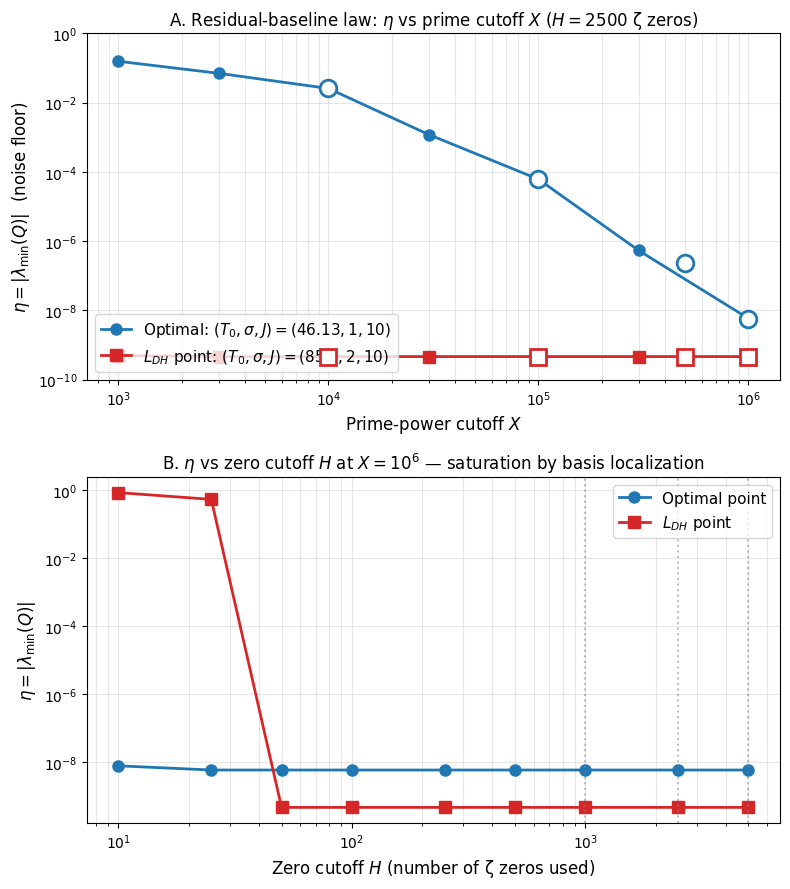

saved figure


In [24]:
# Final figure: 2 subfigures (A: X-dependence at the two parameter points; B: H-dependence 
# saturation at X=1e6)
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# A: η vs X for both parameter points, fine grid, H=2500
ax = axes[0]
X_arr = np.array(X_fine, dtype=float)
y_opt = np.array([fine_results[('optimal', X)] for X in X_fine])
y_ldh = np.array([fine_results[('L_DH', X)] for X in X_fine])
ax.loglog(X_arr, y_opt, 'o-', color='C0', lw=2, ms=8,
 label=r'Optimal: $(T_0,\sigma,J)=(46.13, 1, 10)$')
ax.loglog(X_arr, y_ldh, 's-', color='C3', lw=2, ms=8,
 label=r'$L_{DH}$ point: $(T_0,\sigma,J)=(85.7, 2, 10)$')

# Also overlay the coarse grid points for X={1e4,1e5,5e5,1e6}, H=2500
X_main = np.array(X_grid, dtype=float)
ymain_opt = np.array([results[('optimal', X, 2500)]['abs_lam_min'] for X in X_grid])
ymain_ldh = np.array([results[('L_DH', X, 2500)]['abs_lam_min'] for X in X_grid])
ax.loglog(X_main, ymain_opt, 'o', color='C0', mfc='white', mec='C0', ms=12, mew=2, zorder=10)
ax.loglog(X_main, ymain_ldh, 's', color='C3', mfc='white', mec='C3', ms=12, mew=2, zorder=10)

ax.set_xlabel(r'Prime-power cutoff $X$', fontsize=12)
ax.set_ylabel(r'$\eta = |\lambda_{\min}(Q)|$ (noise floor)', fontsize=12)
ax.set_title(r'A. Residual-baseline law: $\eta$ vs prime cutoff $X$ ($H=2500$ ζ zeros)', fontsize=12)
ax.legend(loc='lower left', fontsize=11)
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(1e-10, 1)

# B: η vs H at X=1e6 for both points (use finer H scan we computed earlier)
ax = axes[1]
# Reconstruct from finer H scan
H_fine_arr = np.array(H_fine, dtype=float)
# Recompute or retrieve. We saved values during cell 19. Let me recompute clearly:
h_data = {'optimal': [], 'L_DH': []}
for name, (T0, sigma, J) in param_points.items():
 M_arch, M_polar = compute_M_arch_polar_v2(T0, sigma, J, n_nodes_quad=400)
 Mp = compute_M_primes_v3(T0, sigma, J, 1_000_000, n_nodes_quad=400)
 for H in H_fine:
 Mz = compute_M_zeros(zeros_arr[:H], T0, sigma, J)
 Q = Mz - (M_polar + M_arch - Mp)
 Q = 0.5*(Q + Q.T)
 lam = np.linalg.eigvalsh(Q)
 h_data[name].append(abs(float(lam[0])))

ax.semilogy(H_fine, h_data['optimal'], 'o-', color='C0', lw=2, ms=8, label=r'Optimal point')
ax.semilogy(H_fine, h_data['L_DH'], 's-', color='C3', lw=2, ms=8, label=r'$L_{DH}$ point')
# Mark required H grid
for H in H_grid:
 ax.axvline(H, color='gray', ls=':', alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel(r'Zero cutoff $H$ (number of ζ zeros used)', fontsize=12)
ax.set_ylabel(r'$\eta = |\lambda_{\min}(Q)|$', fontsize=12)
ax.set_title(r'B. $\eta$ vs zero cutoff $H$ at $X=10^6$ — saturation by basis localization', fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('/workspace/5f29edb4-3009-4bd2-9f9f-6b4d15536790/eta_residual_law.png', dpi=140, bbox_inches='tight')
plt.show()
print("saved figure")


In [25]:

# Final summary table
print("MAIN GRID RESULTS — η = |λ_min(Q)| for ζ")
print("="*70)
for name in ['optimal', 'L_DH']:
 T0,sig,J = param_points[name]
 print(f"\n{name}: (T0,σ,J) = ({T0}, {sig}, {J})")
 print(f" {'X\\H':>10}" + ''.join(f"{H:>13}" for H in H_grid))
 for X in X_grid:
 row = f" {X:>10}"
 for H in H_grid:
 row += f" {abs(results[(name,X,H)]['lam_min']):.4e}"
 print(row)


MAIN GRID RESULTS — η = |λ_min(Q)| for ζ

optimal: (T0,σ,J) = (46.13, 1.0, 10)
 X\H 1000 2500 5000
 10000 2.5596e-02 2.5596e-02 2.5596e-02
 100000 6.0984e-05 6.0984e-05 6.0984e-05
 500000 2.3631e-07 2.3631e-07 2.3631e-07
 1000000 5.7955e-09 5.7955e-09 5.7955e-09

L_DH: (T0,σ,J) = (85.7, 2.0, 10)
 X\H 1000 2500 5000
 10000 4.6197e-10 4.6197e-10 4.6197e-10
 100000 4.6197e-10 4.6197e-10 4.6197e-10
 500000 4.6192e-10 4.6192e-10 4.6192e-10
 1000000 4.6197e-10 4.6197e-10 4.6197e-10
